# 02 — Clean & Label
Apply cleaning rules to the merged 5-minute data and attach depeg labels.

| # | Notebook | Reads → Writes |
|---|----------|----------------|
| 01 | Merge Raw Data | `raw/` → `merged/{coin}_5m_raw.parquet` |
| **▶ 02** | **Clean & Label** | `merged/` → `cleansed/{coin}_5m.parquet` |
| 03 | EDA | `cleansed/` |
| 03b | EDA — Downside Depegs | `cleansed/` |
| 04 | Feature Engineering | `cleansed/` → `features/{coin}_5m_features.parquet` |
| 05 | Build Pooled Dataset | `features/` → `features/pooled_5m.parquet` |
| 06 | Feature-Level EDA | `features/pooled_5m.parquet` |
| 07 | Feature Selection | `features/pooled_5m.parquet` → `features/selected_features.json` |
| 08 | Baseline Models | `features/pooled_5m.parquet` + `selected_features.json` → model results |
| 09 | Final Model (CatBoost) | + `selected_features.json` → `data/models/downside_depeg_catboost.cbm` + `downside_depeg_meta.json` |
| 10 | Threshold & Ops | `data/models/downside_depeg_meta.json` → threshold, alert metrics |
| 11 | LOEO Validation | `data/models/downside_depeg_meta.json` → leave-one-event-out results |
### Cleaning steps
1. **Zero-fill** event columns (on-chain mint/burn, treasury flows, Curve swaps) — absence of an event = zero activity, not missing data
2. **Forward-fill** daily series (FRED macro, Fear & Greed) — published once per day, propagate last known value
3. **Forward-fill** BTC/ETH closes — occasional 5m gaps, safe to forward-fill
4. **Null & forward-fill** CoinAPI price anomalies outside \[0.50, 2.00\] — confirmed feed errors (UST exempt)
5. **Trim** head rows before first valid price

### Labels added
- `price_dev` — `coinapi_close − 1.00` (signed, continuous)
- `depeg` — current bar: `|price_dev| > threshold` for ≥ 3 consecutive bars (either direction); threshold = **1.0% for DAI**, 0.5% for all others
- `depeg_down` — current bar: `price_dev < -threshold` for ≥ 3 consecutive bars (below peg only)
- `depeg_next_1h` — **primary target**: will any depeg occur within the next 12 bars (1 hour)?
- `depeg_next_1h_down` — **downside target**: will a below-peg depeg occur within the next 1 hour?
- `depeg_next_{5min,30min,4h}` / `depeg_next_{5min,30min,4h}_down` — additional horizons

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

# ── Environment detection ─────────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Running in Google Colab — Drive mounted at /content/drive")
else:
    print("Running locally")

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

Running locally


## Configuration
Set paths here before running. Colab users: update `DRIVE_PROJECT_PATH` to match your Google Drive folder.

In [2]:
DRIVE_PROJECT_PATH = "MyDrive/Capstone"   # ← Colab: path inside Google Drive
LOCAL_PROJECT_PATH = None                               # ← Local: set explicit path or None for auto-detect
                                                        #   e.g. "/Users/you/projects/capstone_5min"

if IN_COLAB:
    ROOT = Path("/content/drive") / DRIVE_PROJECT_PATH
elif LOCAL_PROJECT_PATH is not None:
    ROOT = Path(LOCAL_PROJECT_PATH)
else:
    _candidates = [Path.cwd()] + list(Path.cwd().parents)
    ROOT = next((p for p in _candidates if (p / "config" / "settings.py").exists()), None)
    if ROOT is None:
        raise FileNotFoundError(
            "Could not find project root (looked for config/settings.py). "
            "Set LOCAL_PROJECT_PATH above or run from within the project directory."
        )

os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

MERGED_DIR = ROOT / "data" / "processed" / "merged"
OUT_DIR    = ROOT / "data" / "processed" / "cleansed"  # ← change output location if needed

OUT_DIR.mkdir(parents=True, exist_ok=True)

from config.settings import STABLECOINS, DEPEG_THRESHOLD, DEPEG_CONSECUTIVE_BARS, COIN_DEPEG_THRESHOLDS
COINS = list(STABLECOINS.keys())

print(f"Project root:    {ROOT}")
print(f"Input dir:       {MERGED_DIR}")
print(f"Output dir:      {OUT_DIR}")
print(f"Coins:           {COINS}")
print(f"Depeg threshold: ±{DEPEG_THRESHOLD:.1%} default  for ≥{DEPEG_CONSECUTIVE_BARS} consecutive bars")
print(f"Per-coin overrides: {COIN_DEPEG_THRESHOLDS}")

Project root:    /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global
Input dir:       /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global/data/processed/merged
Output dir:      /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global/data/processed/cleansed
Coins:           ['usdt', 'usdc', 'dai', 'busd', 'ust', 'usde', 'rlusd']
Depeg threshold: ±0.5% default  for ≥3 consecutive bars
Per-coin overrides: {'dai': 0.01}


## 1. Null Rates Before Cleaning
Snapshot of null rates per source group in the raw merged files, so we can confirm cleaning fixed them.

## Clean & Label Functions
All cleaning and labeling logic defined inline — no hidden imports from `src/`.

In [3]:
# ── Column groups ─────────────────────────────────────────────────────────────

# Event-based 5m sources: NaN means no events → zero-fill
_EVENT_PREFIXES = (
    "mint_", "burn_", "net_flow_usd",
    "treasury_inflow_", "treasury_outflow_", "treasury_net_flow_usd",
    "tron_treasury_",
    "omni_treasury_",   # Omni Layer (Bitcoin) USDT treasury flows
    "curve_",
    "sol_",    # USDC Solana mint/burn/net_flow
    "xrpl_",   # RLUSD XRPL mint/burn/net_flow
)

# Daily series: NaN means no new value published → forward-fill
_DAILY_COLS = ["dxy", "vix", "t10y", "fedfunds", "fear_greed"]

# 5m market context with occasional gaps → forward-fill
_FFILL_5M_COLS = ["binance_btc_close", "binance_eth_close"]

# CoinAPI price bounds — outside these is a feed error; UST exempt (real collapse)
_COINAPI_PRICE_COLS = ["coinapi_open", "coinapi_high", "coinapi_low", "coinapi_close"]
_COINAPI_LO, _COINAPI_HI = 0.50, 2.0
_COINAPI_PRICE_EXEMPT = {"ust"}

# Depeg labeling settings (loaded from config but re-stated here for visibility)
_ALLOW_EXTREME_PRICES = {"ust"}
_OUTLIER_LO, _OUTLIER_HI = 0.50, 2.0
_HORIZONS = [("5min", 1), ("30min", 6), ("1h", 12), ("4h", 48), ("12h", 144), ("24h", 288)]


def _is_event_col(col):
    return any(col == p or col.startswith(p) for p in _EVENT_PREFIXES)


# ── clean_coin ────────────────────────────────────────────────────────────────

def clean_coin(coin_key):
    """Clean a merged raw parquet file. Returns cleaned DataFrame."""
    raw_path = MERGED_DIR / f"{coin_key}_5m_raw.parquet"
    if not raw_path.exists():
        print(f"  Raw file not found: {raw_path.name} — run 01_merge_raw_data.ipynb first.")
        return pd.DataFrame()

    df = pd.read_parquet(raw_path)
    print(f"  Loaded {len(df):,} rows, {df.shape[1]} columns")

    # 1. Zero-fill event-based columns
    event_cols = [c for c in df.columns if _is_event_col(c)]
    if event_cols:
        df[event_cols] = df[event_cols].fillna(0)
        print(f"  Zero-filled {len(event_cols)} event columns")

    # 2. Forward-fill daily series
    daily_cols = [c for c in _DAILY_COLS if c in df.columns]
    if daily_cols:
        df[daily_cols] = df[daily_cols].ffill()
        print(f"  Forward-filled daily cols: {daily_cols}")

    # 3. Forward-fill 5m market context gaps
    ffill_cols = [c for c in _FFILL_5M_COLS if c in df.columns]
    if ffill_cols:
        df[ffill_cols] = df[ffill_cols].ffill()
        print(f"  Forward-filled 5m market cols: {ffill_cols}")

    # 4. Null and forward-fill CoinAPI price anomalies
    price_cols = [c for c in _COINAPI_PRICE_COLS if c in df.columns]
    if price_cols and "coinapi_close" in df.columns:
        if coin_key not in _COINAPI_PRICE_EXEMPT:
            bad_mask = (df["coinapi_close"] < _COINAPI_LO) | (df["coinapi_close"] > _COINAPI_HI)
            n_bad = int(bad_mask.sum())
            if n_bad:
                df.loc[bad_mask, price_cols] = pd.NA
                print(f"  Nulled {n_bad} CoinAPI price anomalies")
        n_null = int(df["coinapi_close"].isna().sum())
        if n_null:
            df[price_cols] = df[price_cols].ffill()
            print(f"  Forward-filled {n_null} CoinAPI gaps")

    # 5. Trim head rows before first valid price
    head_cols = [c for c in ["coinapi_close", "binance_btc_close", "binance_eth_close"]
                 if c in df.columns]
    first_valids = [df[c].first_valid_index() for c in head_cols]
    first_valids = [ts for ts in first_valids if ts is not None]
    if first_valids:
        trim_to = max(first_valids)
        if trim_to != df.index[0]:
            n_trimmed = df.index.get_loc(trim_to)
            df = df.loc[trim_to:]
            print(f"  Trimmed {n_trimmed} head rows → first valid: {trim_to}")

    # Summary of remaining nulls
    remaining_nulls = df.isnull().sum()
    remaining_nulls = remaining_nulls[remaining_nulls > 0]
    if not remaining_nulls.empty:
        print(f"  Remaining nulls (expected sparse / tail rows):")
        for col, n in remaining_nulls.sort_values(ascending=False).head(5).items():
            print(f"    {col}: {n/len(df)*100:.1f}%")

    return df


def save_clean(df, coin_key):
    path = OUT_DIR / f"{coin_key}_5m.parquet"
    df.to_parquet(path)
    size_mb = path.stat().st_size / 1e6
    print(f"  Saved cleaned → {path.name}  ({len(df):,} rows, {size_mb:.1f} MB)")


# ── label_coin ────────────────────────────────────────────────────────────────

def label_coin(coin_key):
    """Add depeg labels to a cleaned parquet file. Returns labeled DataFrame."""
    path = OUT_DIR / f"{coin_key}_5m.parquet"
    df = pd.read_parquet(path)

    coin_threshold = COIN_DEPEG_THRESHOLDS.get(coin_key, DEPEG_THRESHOLD)

    price = df["coinapi_close"].copy()

    # Null obvious feed errors (non-failed coins only)
    if coin_key not in _ALLOW_EXTREME_PRICES:
        bad = (price < _OUTLIER_LO) | (price > _OUTLIER_HI)
        if bad.sum():
            price[bad] = pd.NA

    # Continuous deviation from $1.00
    df["price_dev"] = (price - 1.0).astype("float64")

    # Current-state depeg label (either direction)
    single_breach = df["price_dev"].abs() > coin_threshold
    df["depeg"] = (
        single_breach
        .rolling(DEPEG_CONSECUTIVE_BARS, min_periods=DEPEG_CONSECUTIVE_BARS)
        .min()
        .astype("Int8")
    )
    df.loc[price.isna(), "depeg"] = pd.NA

    # Current-state depeg_down label (below peg only)
    single_breach_down = df["price_dev"] < -coin_threshold
    df["depeg_down"] = (
        single_breach_down
        .rolling(DEPEG_CONSECUTIVE_BARS, min_periods=DEPEG_CONSECUTIVE_BARS)
        .min()
        .astype("Int8")
    )
    df.loc[price.isna(), "depeg_down"] = pd.NA

    # Forward-looking labels (both directions and downside-only)
    depeg_f      = df["depeg"].astype(float)
    depeg_down_f = df["depeg_down"].astype(float)
    for suffix, bars in _HORIZONS:
        fwd      = depeg_f.rolling(bars, min_periods=bars).max().shift(-bars)
        fwd_down = depeg_down_f.rolling(bars, min_periods=bars).max().shift(-bars)
        df[f"depeg_next_{suffix}"]      = fwd.astype("Int8")
        df[f"depeg_next_{suffix}_down"] = fwd_down.astype("Int8")

    print(f"  threshold: ±{coin_threshold:.1%}  |  depeg rate (current): {df['depeg'].mean():.2%}  |  "
          f"depeg_down rate: {df['depeg_down'].mean():.2%}  |  "
          f"depeg_next_1h: {df['depeg_next_1h'].mean():.2%}  |  "
          f"depeg_next_1h_down: {df['depeg_next_1h_down'].mean():.2%}  |  "
          f"rows: {len(df):,}")
    return df


def save_label(df, coin_key):
    path = OUT_DIR / f"{coin_key}_5m.parquet"
    df.to_parquet(path)
    print(f"  Saved labeled  → {path.name}")


In [4]:
GROUPS = {
    "CoinAPI price":     lambda c: c.startswith("coinapi_"),
    "BTC/ETH closes":    lambda c: c in ["binance_btc_close", "binance_eth_close"],
    "FRED macro":        lambda c: c in ["dxy", "vix", "t10y", "fedfunds"],
    "Fear & Greed":      lambda c: c == "fear_greed",
    "On-chain ETH":      lambda c: any(c.startswith(p) for p in ["mint_", "burn_", "net_flow", "treasury"]),
    "TRON treasury":     lambda c: c.startswith("tron_"),
    "Omni treasury":     lambda c: c.startswith("omni_"),
    "Curve DEX":         lambda c: c.startswith("curve_"),
    "Solana":            lambda c: c.startswith("sol_"),
    "XRPL":              lambda c: c.startswith("xrpl_"),
}

def null_rates(df):
    row = {}
    for grp, pred in GROUPS.items():
        cols = [c for c in df.columns if pred(c)]
        row[grp] = df[cols].isnull().mean().mean() if cols else np.nan
    return row

before_rows = []
for coin in COINS:
    raw = pd.read_parquet(MERGED_DIR / f"{coin}_5m_raw.parquet")
    r = {"coin": coin.upper()} | {k: f"{v:.0%}" if not np.isnan(v) else "—"
                                   for k, v in null_rates(raw).items()}
    before_rows.append(r)

pd.DataFrame(before_rows).set_index("coin").style\
    .set_caption("Null rates BEFORE cleaning")\
    .set_table_styles([{"selector": "th", "props": [("background-color", "#1A2E4A"), ("color", "white")]}])


,CoinAPI price,BTC/ETH closes,FRED macro,Fear & Greed,On-chain ETH,TRON treasury,Omni treasury,Curve DEX,Solana,XRPL
coin,,,,,,,,,,
USDT,0%,0%,0%,5%,99%,99%,100%,69%,—,—
USDC,0%,0%,0%,0%,50%,—,—,64%,81%,—
DAI,0%,0%,0%,0%,49%,—,—,67%,—,—
BUSD,0%,0%,0%,0%,99%,—,—,100%,—,—
UST,0%,0%,0%,0%,—,—,—,100%,—,—
USDE,0%,0%,0%,0%,89%,—,—,74%,—,—
RLUSD,1%,0%,0%,0%,100%,—,—,92%,—,98%


## 2. Clean & Label All Coins

In [5]:
cleansed = {}
for coin in COINS:
    print(f"\n{'='*50}  {coin.upper()}  {'='*50}")
    df = clean_coin(coin)
    if df.empty:
        continue
    save_clean(df, coin)
    df = label_coin(coin)
    save_label(df, coin)
    cleansed[coin] = df


==================================================  USDT  ==================================================
  Loaded 897,984 rows, 64 columns
  Zero-filled 35 event columns


  Forward-filled daily cols: ['dxy', 'vix', 't10y', 'fedfunds', 'fear_greed']
  Forward-filled 5m market cols: ['binance_btc_close', 'binance_eth_close']
  Nulled 40 CoinAPI price anomalies
  Forward-filled 1502 CoinAPI gaps
  Trimmed 48 head rows → first valid: 2017-08-17 04:00:00+00:00
  Remaining nulls (expected sparse / tail rows):
    binance_usdcusdt_buy_ratio: 21.2%
    binance_usdcusdt_open: 21.0%
    binance_usdcusdt_high: 21.0%
    binance_usdcusdt_low: 21.0%
    binance_usdcusdt_close: 21.0%


  Saved cleaned → usdt_5m.parquet  (897,936 rows, 85.8 MB)


  threshold: ±0.5%  |  depeg rate (current): 9.12%  |  depeg_down rate: 2.72%  |  depeg_next_1h: 9.92%  |  depeg_next_1h_down: 2.97%  |  rows: 897,936


  Saved labeled  → usdt_5m.parquet

==================================================  USDC  ==================================================
  Loaded 775,584 rows, 76 columns
  Zero-filled 25 event columns


...

  Zero-filled 20 event columns
  Forward-filled daily cols: ['dxy', 'vix', 't10y', 'fedfunds', 'fear_greed']
  Forward-filled 5m market cols: ['binance_btc_close', 'binance_eth_close']
  Forward-filled 346 CoinAPI gaps
  Remaining nulls (expected sparse / tail rows):
    coinapi_tick_count: 0.2%
  Saved cleaned → ust_5m.parquet  (153,961 rows, 9.4 MB)


  threshold: ±0.5%  |  depeg rate (current): 5.31%  |  depeg_down rate: 1.97%  |  depeg_next_1h: 6.19%  |  depeg_next_1h_down: 2.24%  |  rows: 153,961
  Saved labeled  → ust_5m.parquet

==================================================  USDE  ==================================================
  Loaded 201,024 rows, 33 columns
  Zero-filled 15 event columns
  Forward-filled daily cols: ['dxy', 'vix', 't10y', 'fedfunds', 'fear_greed']
  Forward-filled 5m market cols: ['binance_btc_close', 'binance_eth_close']
  Forward-filled 477 CoinAPI gaps
  Trimmed 96 head rows → first valid: 2024-04-02 08:00:00+00:00
  Remaining nulls (expected sparse / tail rows):
    coinapi_tick_count: 0.2%


  Saved cleaned → usde_5m.parquet  (200,928 rows, 14.9 MB)
  threshold: ±0.5%  |  depeg rate (current): 0.05%  |  depeg_down rate: 0.04%  |  depeg_next_1h: 0.10%  |  depeg_next_1h_down: 0.10%  |  rows: 200,928


  Saved labeled  → usde_5m.parquet

==================================================  RLUSD  ==================================================
  Loaded 96,192 rows, 38 columns
  Zero-filled 20 event columns
  Forward-filled daily cols: ['dxy', 'vix', 't10y', 'fedfunds', 'fear_greed']
  Forward-filled 5m market cols: ['binance_btc_close', 'binance_eth_close']
  Forward-filled 652 CoinAPI gaps
  Remaining nulls (expected sparse / tail rows):
    coinapi_tick_count: 0.7%
  Saved cleaned → rlusd_5m.parquet  (96,192 rows, 6.3 MB)
  threshold: ±0.5%  |  depeg rate (current): 0.00%  |  depeg_down rate: 0.00%  |  depeg_next_1h: 0.00%  |  depeg_next_1h_down: 0.00%  |  rows: 96,192


  Saved labeled  → rlusd_5m.parquet


## 3. Null Rates After Cleaning
Event columns should be 0%, daily columns should be near 0% (only tail rows).

In [6]:
after_rows = []
for coin, df in cleansed.items():
    r = {"coin": coin.upper()} | {k: f"{v:.0%}" if not np.isnan(v) else "—"
                                   for k, v in null_rates(df).items()}
    after_rows.append(r)

pd.DataFrame(after_rows).set_index("coin").style\
    .set_caption("Null rates AFTER cleaning")\
    .set_table_styles([{"selector": "th", "props": [("background-color", "#1A2E4A"), ("color", "white")]}])

,CoinAPI price,BTC/ETH closes,FRED macro,Fear & Greed,On-chain ETH,TRON treasury,Omni treasury,Curve DEX,Solana,XRPL
coin,,,,,,,,,,
USDT,0%,0%,0%,5%,0%,0%,0%,0%,—,—
USDC,0%,0%,0%,0%,0%,—,—,0%,0%,—
DAI,0%,0%,0%,0%,0%,—,—,0%,—,—
BUSD,0%,0%,0%,0%,0%,—,—,0%,—,—
UST,0%,0%,0%,0%,—,—,—,0%,—,—
USDE,0%,0%,0%,0%,0%,—,—,0%,—,—
RLUSD,0%,0%,0%,0%,0%,—,—,0%,—,0%


## 4. Depeg Label Summary
Depeg rate per coin for the current-state label and the 1-hour forward-looking target.

In [7]:
label_rows = []
for coin, df in cleansed.items():
    episodes = int((df["depeg"].diff().fillna(df["depeg"]) == 1).sum())
    episodes_down = int((df["depeg_down"].diff().fillna(df["depeg_down"]) == 1).sum())
    label_rows.append({
        "coin":                  coin.upper(),
        "rows":                  f"{len(df):,}",
        "depeg % (current)":     f"{df['depeg'].mean():.2%}",
        "depeg_down % (current)":f"{df['depeg_down'].mean():.2%}",
        "depeg_next_1h %":       f"{df['depeg_next_1h'].mean():.2%}",
        "depeg_next_1h_down %":  f"{df['depeg_next_1h_down'].mean():.2%}",
        "episodes":              episodes,
        "episodes_down":         episodes_down,
        "date range":            f"{df.index.min().date()} → {df.index.max().date()}",
    })

label_df = pd.DataFrame(label_rows).set_index("coin")
label_df.style\
    .set_caption("Depeg label statistics per coin")\
    .set_table_styles([{"selector": "th", "props": [("background-color", "#1A2E4A"), ("color", "white")]}])

,rows,depeg % (current),depeg_down % (current),depeg_next_1h %,depeg_next_1h_down %,episodes,episodes_down,date range
coin,,,,,,,,
USDT,"897,936",9.12%,2.72%,9.92%,2.97%,921,281,2017-08-17 → 2026-02-28
USDC,"775,506",5.59%,0.19%,5.93%,0.26%,341,62,2018-10-16 → 2026-02-28
DAI,"828,963",10.67%,1.95%,11.89%,2.23%,1316,311,2018-04-13 → 2026-02-28
BUSD,"370,848",0.28%,0.00%,0.38%,0.00%,50,0,2019-09-20 → 2023-03-31
UST,"153,961",5.31%,1.97%,6.19%,2.24%,188,57,2020-11-23 → 2022-05-12
USDE,"200,928",0.05%,0.04%,0.10%,0.10%,15,14,2024-04-02 → 2026-02-28
RLUSD,"96,192",0.00%,0.00%,0.00%,0.00%,0,0,2025-04-01 → 2026-02-28


## 5. Price Deviation Distribution
`price_dev = coinapi_close − 1.00`. The tails reveal how severe and frequent depegs are per coin. Note UST's extreme left tail from the May 2022 collapse.

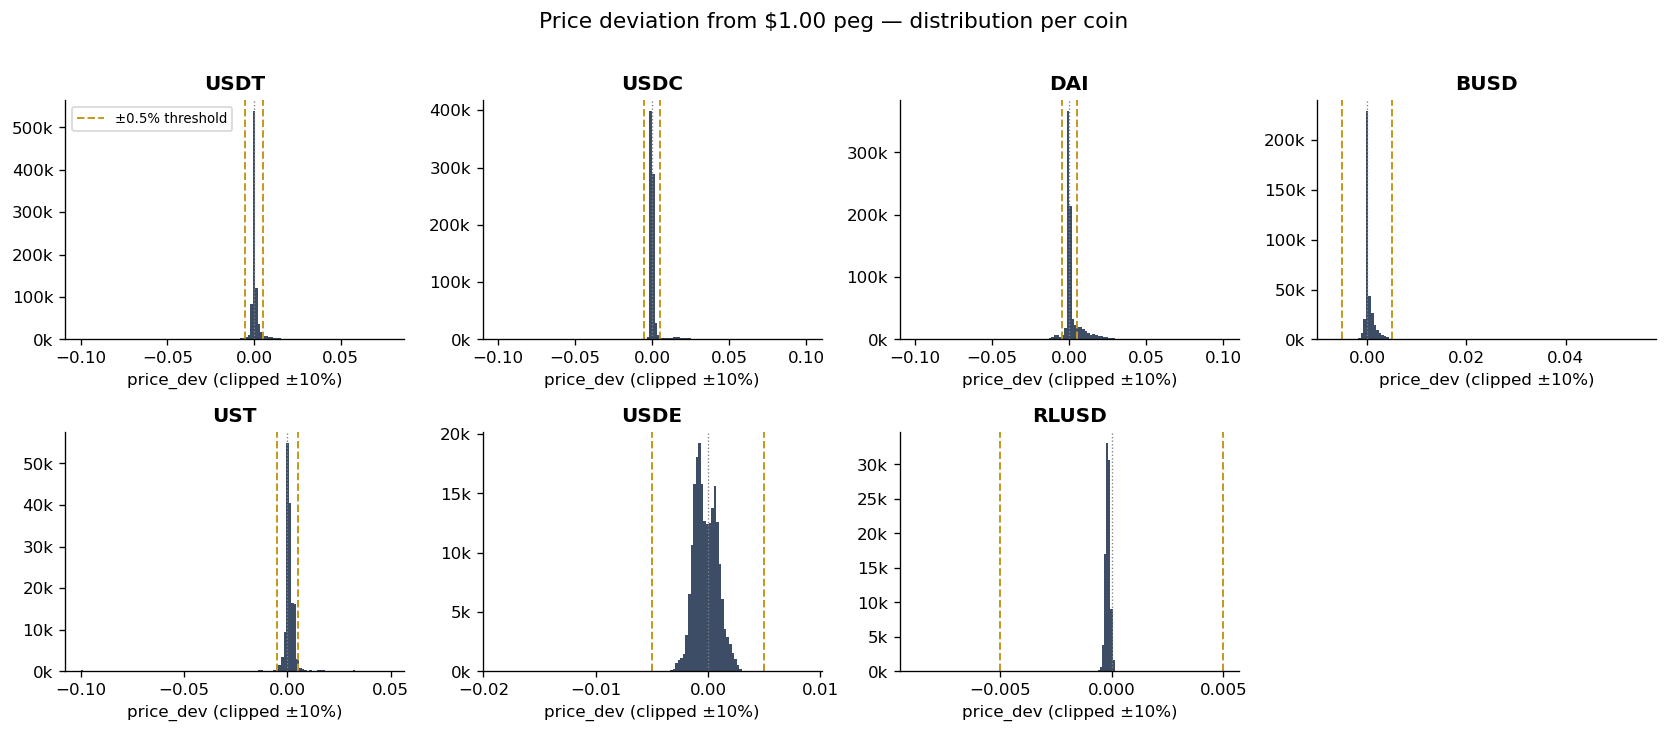

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharey=False)
axes = axes.flatten()

for ax, (coin, df) in zip(axes, cleansed.items()):
    dev = df["price_dev"].dropna()
    # Clip at ±10% for readability (UST goes to -1.0)
    clip = dev.clip(-0.10, 0.10)
    ax.hist(clip, bins=120, color="#1A2E4A", edgecolor="none", alpha=0.85)
    ax.axvline(0.005,  color="#C49A22", lw=1.2, ls="--", label="±0.5% threshold")
    ax.axvline(-0.005, color="#C49A22", lw=1.2, ls="--")
    ax.axvline(0, color="gray", lw=0.8, ls=":")
    ax.set_title(coin.upper(), fontweight="bold")
    ax.set_xlabel("price_dev (clipped ±10%)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

axes[0].legend(fontsize=8)
# Hide unused subplot
for ax in axes[len(cleansed):]:
    ax.set_visible(False)

fig.suptitle("Price deviation from $1.00 peg — distribution per coin", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Key Depeg Events — Price Timeline
Two landmark events: the **UST collapse (May 2022)** and the **USDC Silicon Valley Bank depeg (March 2023)**.

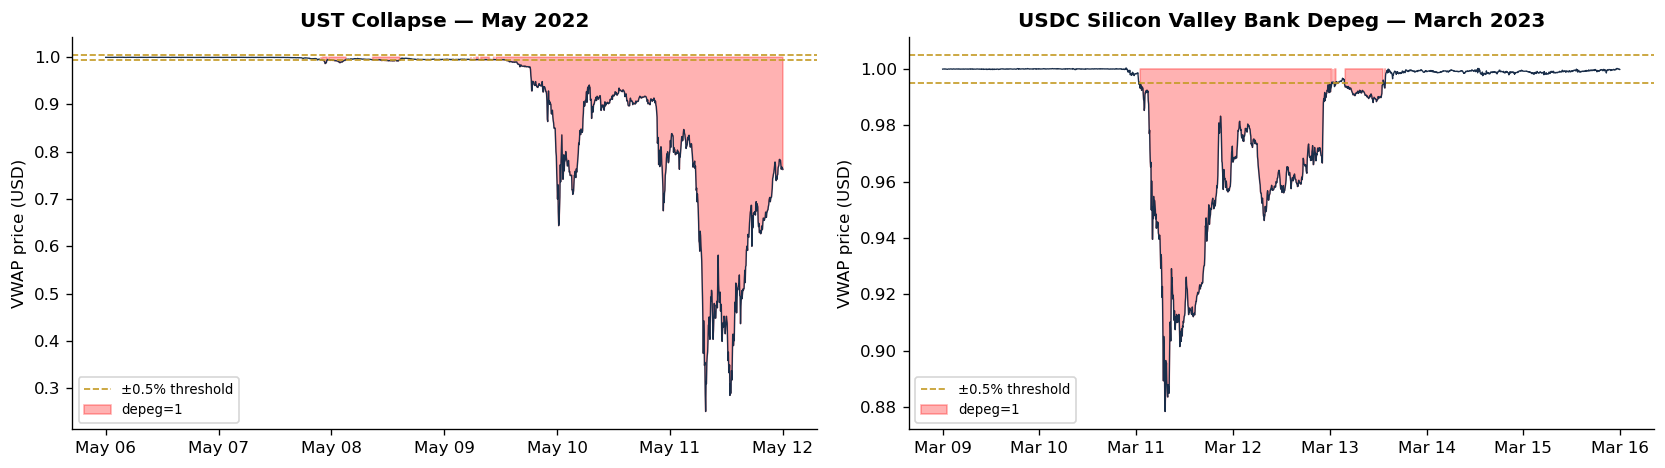

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# UST collapse
ust = cleansed["ust"].loc["2022-05-06":"2022-05-14"]
ax = axes[0]
ax.plot(ust.index, ust["coinapi_close"], color="#1A2E4A", lw=0.8)
ax.axhline(0.995, color="#C49A22", lw=1, ls="--", label="±0.5% threshold")
ax.axhline(1.005, color="#C49A22", lw=1, ls="--")
ax.fill_between(ust.index, ust["coinapi_close"], 1.0,
                where=ust["depeg"] == 1, alpha=0.3, color="red", label="depeg=1")
ax.set_title("UST Collapse — May 2022", fontweight="bold")
ax.set_ylabel("VWAP price (USD)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend(fontsize=8)

# USDC SVB depeg
usdc = cleansed["usdc"].loc["2023-03-09":"2023-03-15"]
ax = axes[1]
ax.plot(usdc.index, usdc["coinapi_close"], color="#1A2E4A", lw=0.8)
ax.axhline(0.995, color="#C49A22", lw=1, ls="--", label="±0.5% threshold")
ax.axhline(1.005, color="#C49A22", lw=1, ls="--")
ax.fill_between(usdc.index, usdc["coinapi_close"], 1.0,
                where=usdc["depeg"] == 1, alpha=0.3, color="red", label="depeg=1")
ax.set_title("USDC Silicon Valley Bank Depeg — March 2023", fontweight="bold")
ax.set_ylabel("VWAP price (USD)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7. Target Label — Class Balance
`depeg_next_1h` is the modeling target. Note the severe class imbalance — the model will need `scale_pos_weight` or PR-AUC as the evaluation metric.

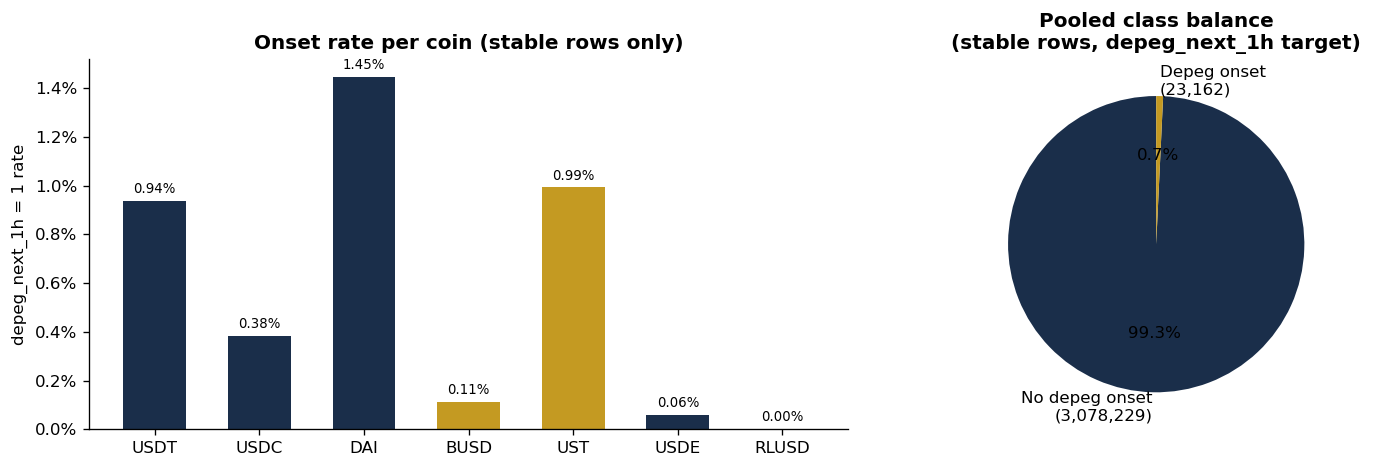


Pooled onset rate: 0.75%  (23,162 positive / 3,101,391 total stable rows)


In [10]:
# Onset-only: stable rows (depeg=0) — the correctly scoped training population
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: overall depeg_next_1h rate per coin
coins_list = list(cleansed.keys())
onset_rates = [
    cleansed[c].loc[cleansed[c]["depeg"] == 0, "depeg_next_1h"].mean()
    for c in coins_list
]
colors = ["#C49A22" if c in ("ust", "busd") else "#1A2E4A" for c in coins_list]
axes[0].bar([c.upper() for c in coins_list], onset_rates, color=colors, width=0.6)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1%}"))
axes[0].set_title("Onset rate per coin (stable rows only)", fontweight="bold")
axes[0].set_ylabel("depeg_next_1h = 1 rate")
for i, (v, c) in enumerate(zip(onset_rates, coins_list)):
    axes[0].text(i, v + 0.0002, f"{v:.2%}", ha="center", va="bottom", fontsize=8)

# Right: pooled class balance pie
total_stable = sum(
    (cleansed[c]["depeg"] == 0).sum() for c in coins_list
)
total_onset = sum(
    cleansed[c].loc[cleansed[c]["depeg"] == 0, "depeg_next_1h"].sum()
    for c in coins_list
)
axes[1].pie(
    [total_stable - total_onset, total_onset],
    labels=[f"No depeg onset\n({total_stable - total_onset:,.0f})", 
            f"Depeg onset\n({total_onset:,.0f})"],
    colors=["#1A2E4A", "#C49A22"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 10},
)
axes[1].set_title("Pooled class balance\n(stable rows, depeg_next_1h target)", fontweight="bold")

plt.tight_layout()
plt.show()
print(f"\nPooled onset rate: {total_onset/total_stable:.2%}  ({total_onset:,.0f} positive / {total_stable:,.0f} total stable rows)")

## 8. Next Step
Run `03_eda.ipynb` to explore the cleaned and labeled data.